## 1) Setup

In [ ]:
# Install dependencies
!pip -q install textblob wordcloud missingno plotly seaborn

import warnings
warnings.filterwarnings('ignore')

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from textblob import TextBlob
from wordcloud import WordCloud

import plotly.graph_objects as go
from plotly.offline import init_notebook_mode
init_notebook_mode(connected=True)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

print('Libraries loaded.')

Libraries loaded.


## 2) Dataset loading

In [ ]:
DATA_PATH = Path('/content/stockbit_reviews_clean.csv')

if not DATA_PATH.exists():
    print('CSV tidak ditemukan di:', DATA_PATH.resolve())
    print('Jika membuka dari GitHub di Colab, clone repo dulu lalu %cd ke folder repo, contoh:')
    print('  !git clone https://github.com/<username>/<repo>.git')
    print('  %cd <repo>')
    raise FileNotFoundError('csv/stockbit_reviews_clean.csv tidak ditemukan')

df_stockbit_clean = pd.read_csv(DATA_PATH)
df_stockbit_clean.head()

,content,score,at,thumbsUpCount,replyContent,sentiment,final_text,tokens_stemmed
0,mantap,5,2026-03-28 10:49:16,0,NaN,positive,bagus,['bagus']
1,Keren. Sangat membantu. Tapi sayangnya belum a...,5,2026-03-28 10:04:59,11,"Halo kak bujanggila,\n\nTerima kasih atas upda...",positive,bagus sangat bantu sayang trailing stop ayo ja...,"['bagus', 'sangat', 'bantu', 'sayang', 'traili..."
2,udh nunggu lama bgt lebih dari waktu yg di bil...,1,2026-03-28 09:19:54,0,"Halo kak Giffa,\n\nUntuk verifikasi data membu...",negative,nunggu lama banget lebih waktu bilanghari muda...,"['nunggu', 'lama', 'banget', 'lebih', 'waktu',..."
3,penipuan,1,2026-03-28 08:59:03,0,NaN,negative,tipu,['tipu']
4,aplikasi investasi yang sngat dipercaya,5,2026-03-28 04:08:53,0,NaN,positive,investasi sngat percaya,"['investasi', 'sngat', 'percaya']"


In [ ]:
df_stockbit_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13592 entries, 0 to 13591
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   content         13592 non-null  object
 1   score           13592 non-null  int64 
 2   at              13592 non-null  object
 3   thumbsUpCount   13592 non-null  int64 
 4   replyContent    11679 non-null  object
 5   sentiment       13592 non-null  object
 6   final_text      13592 non-null  object
 7   tokens_stemmed  13592 non-null  object
dtypes: int64(2), object(6)
memory usage: 849.6+ KB


## 3) TextBlob — sentiment scoring

Menghitung `sentiment_polarity` dan `sentiment_subjectivity` dari teks hasil preprocessing (`final_text`).

In [ ]:
required_cols = {'content', 'final_text'}
missing = required_cols - set(df_stockbit_clean.columns)
if missing:
    raise ValueError(f'Kolom wajib tidak ada: {sorted(missing)}')

final_text_series = df_stockbit_clean['final_text'].fillna('').astype(str)

df_stockbit_clean['sentiment_polarity'] = final_text_series.apply(
    lambda x: TextBlob(x).sentiment.polarity
)
df_stockbit_clean['sentiment_subjectivity'] = final_text_series.apply(
    lambda x: TextBlob(x).sentiment.subjectivity
)

print('Sentiment polarity & subjectivity computed.')
df_stockbit_clean[['content', 'final_text', 'sentiment_polarity', 'sentiment_subjectivity']].head(5)


Sentiment polarity & subjectivity computed.


,content,final_text,sentiment_polarity,sentiment_subjectivity
0,mantap,bagus,0.0,0.000000
1,Keren. Sangat membantu. Tapi sayangnya belum a...,bagus sangat bantu sayang trailing stop ayo ja...,0.0,0.357143
2,udh nunggu lama bgt lebih dari waktu yg di bil...,nunggu lama banget lebih waktu bilanghari muda...,0.0,0.000000
3,penipuan,tipu,0.0,0.000000
4,aplikasi investasi yang sngat dipercaya,investasi sngat percaya,0.0,0.000000


In [ ]:
if 'sentiment' in df_stockbit_clean.columns:
    print('Distribusi sentiment label:')
    display(df_stockbit_clean['sentiment'].value_counts(dropna=False))
    print('\nProporsi (%):')
    display((df_stockbit_clean['sentiment'].value_counts(normalize=True) * 100).round(2))
else:
    print('Kolom sentiment tidak ada. (Opsional)')


Distribusi sentiment label:


,count
sentiment,
positive,8416
negative,4257
neutral,919



Proporsi (%):


,proportion
sentiment,
positive,61.92
negative,31.32
neutral,6.76


## 4) EDA — Exploratory Data Analysis

In [ ]:
df_stockbit_clean.sample(5, random_state=42)

,content,score,at,thumbsUpCount,replyContent,sentiment,final_text,tokens_stemmed,sentiment_polarity,sentiment_subjectivity
1061,sangat baik dan efesien bagi pemula yang mulai...,5,2025-12-24 03:31:38,0,"Halo kak seni farm,\n\nSenang sekali baca revi...",positive,sangat baik efesien mula mulai mengenalinvestasi,"['sangat', 'baik', 'efesien', 'mula', 'mulai',...",0.0,0.0
3881,Aplikasi sangat bagus dan mudah digunakan,5,2025-04-21 10:21:53,0,"Halo kak Nugroho,\n\nKami senang kakak menyuka...",positive,sangat bagus mudah guna,"['sangat', 'bagus', 'mudah', 'guna']",0.0,0.0
3563,"Invest kriptonya segera dirilis, biar ga ribet...",3,2025-06-06 14:50:00,0,"Halo kak 77,\n\nSaran yang kakak berikan sudah...",neutral,invest kriptonya segera rilis biar ribet pinda...,"['invest', 'kriptonya', 'segera', 'rilis', 'bi...",0.0,0.0
7275,"Sedikit2 beralih kesekuritas lain,, mulai bula...",1,2023-03-31 13:31:50,0,NaN,negative,sedikit alih sekuritas mulai bulan depan mulai...,"['sedikit', 'alih', 'sekuritas', 'mulai', 'bul...",0.0,0.0
6654,app paling rekomended.. 👌,5,2023-09-05 06:47:09,0,"Halo kak Oyku Azahra,\n\nKami senang kakak men...",positive,paling rekomended,"['paling', 'rekomended']",0.0,0.0


In [ ]:
df_stockbit_clean.isnull().sum().sort_values(ascending=False).head(20)

,0
replyContent,1913
content,0
score,0
at,0
thumbsUpCount,0
sentiment,0
final_text,0
tokens_stemmed,0
sentiment_polarity,0
sentiment_subjectivity,0


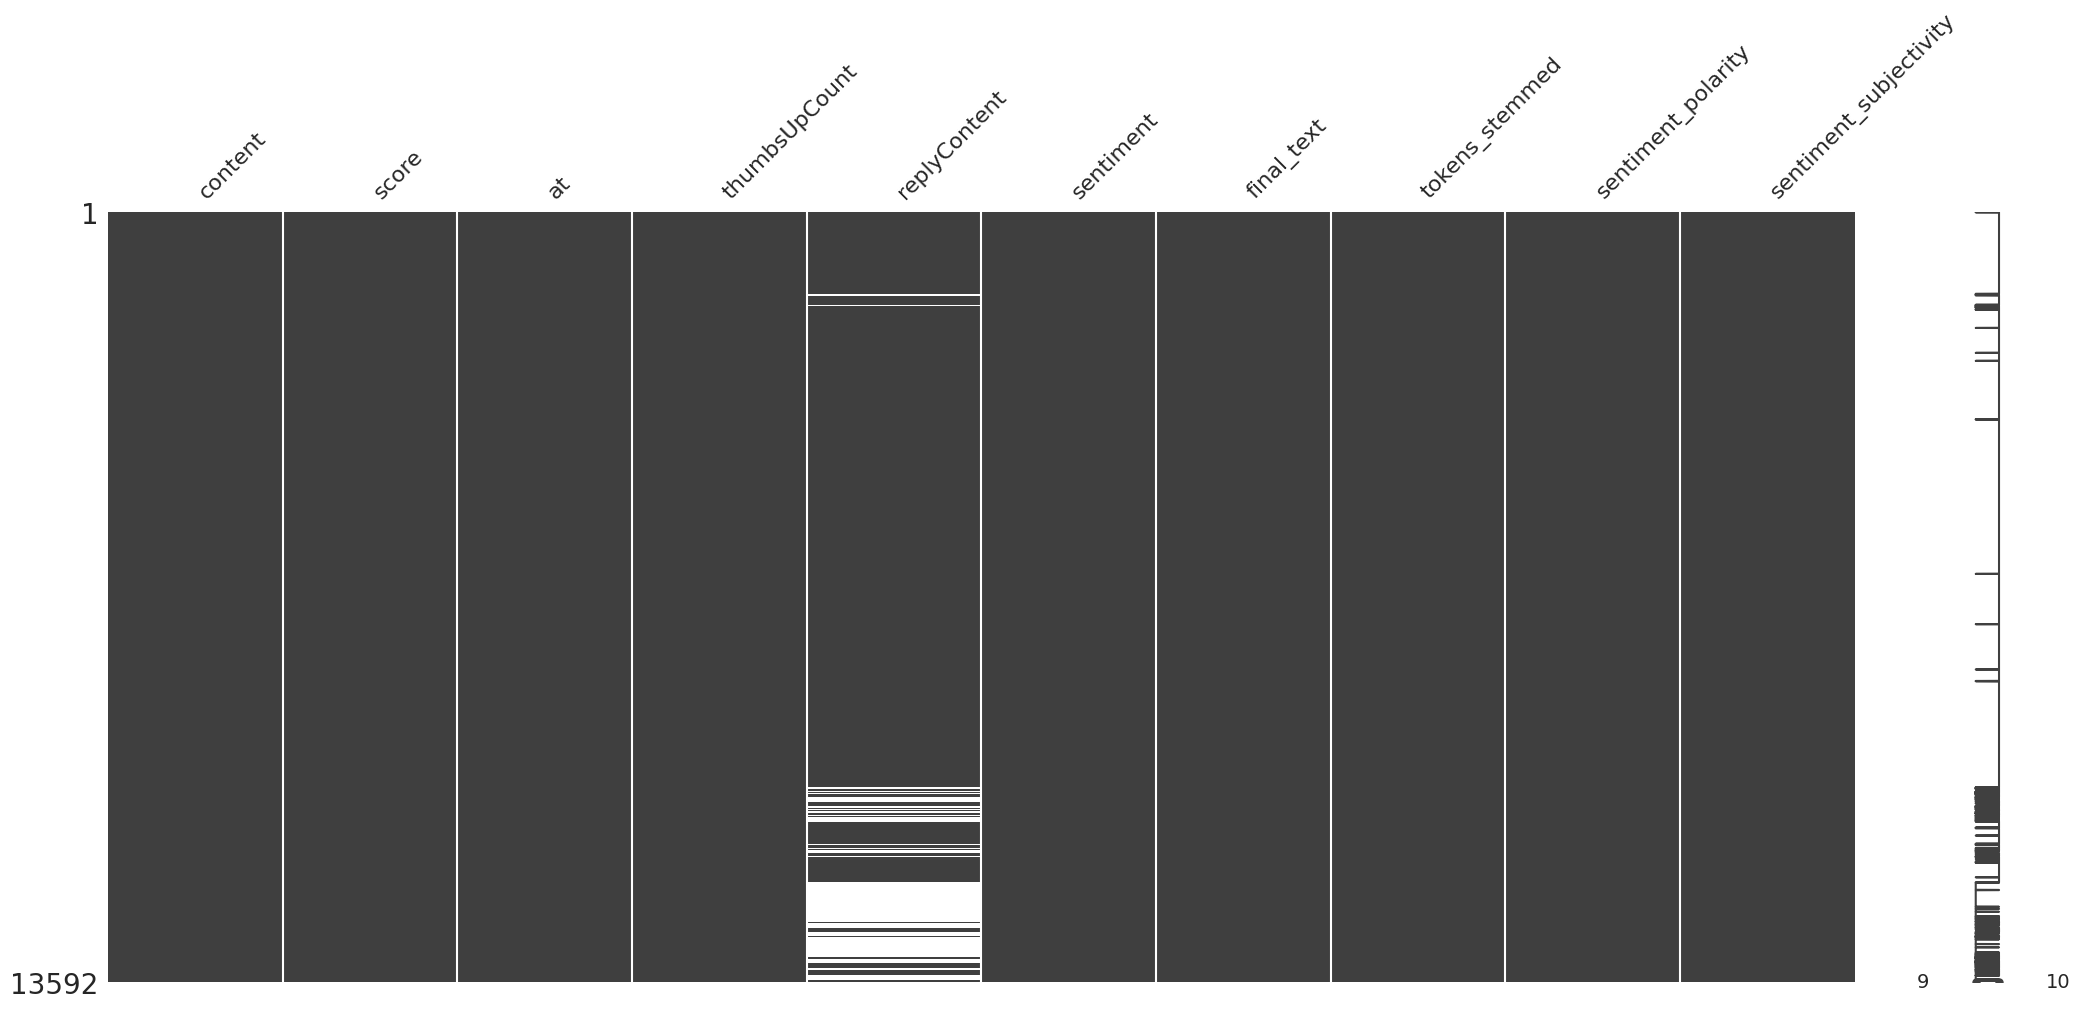

In [ ]:
msno.matrix(df_stockbit_clean)
plt.show()

### Scatter Plot: Polarity vs Subjectivity

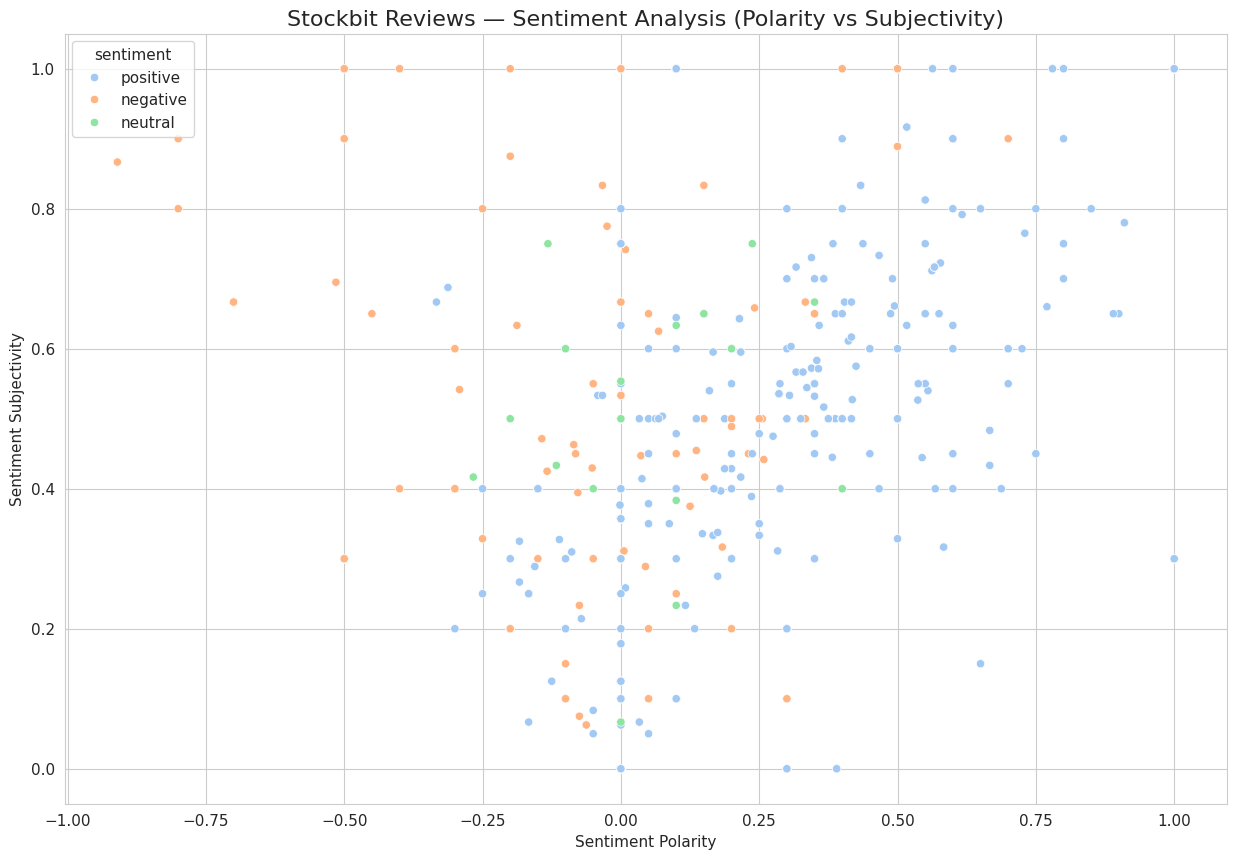

In [ ]:
plt.figure(figsize=(15, 10))
sns.scatterplot(
    x=df_stockbit_clean['sentiment_polarity'],
    y=df_stockbit_clean['sentiment_subjectivity'],
    hue=df_stockbit_clean['sentiment'] if 'sentiment' in df_stockbit_clean.columns else None,
    edgecolor='white',
    palette='pastel',
)
plt.title('Stockbit Reviews — Sentiment Analysis (Polarity vs Subjectivity)', fontsize=16)
plt.xlabel('Sentiment Polarity')
plt.ylabel('Sentiment Subjectivity')
plt.show()

### Most Frequent Words

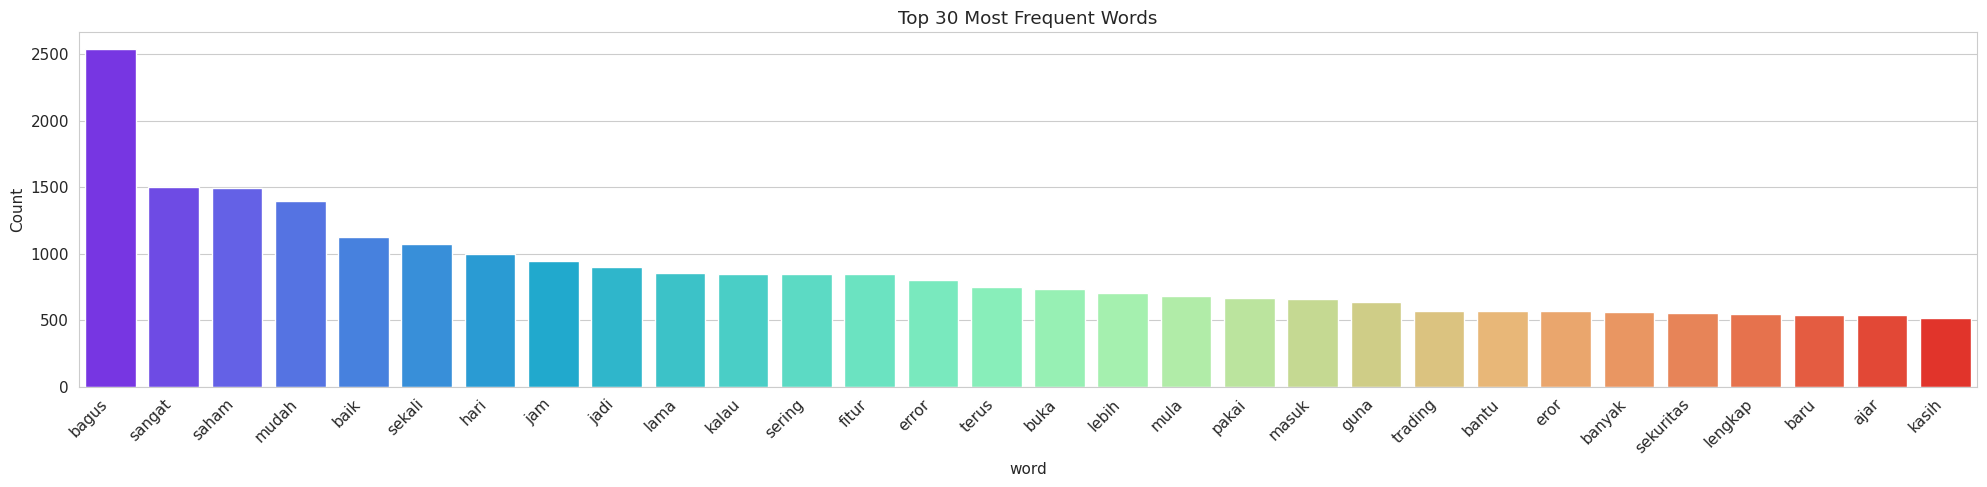

In [ ]:
import nltk
from nltk.probability import FreqDist
nltk.download('punkt', quiet=True)

def freq_words(x, terms=30):
    all_words = ' '.join([str(text) for text in x if isinstance(text, str)])
    all_words = all_words.split()
    fdist = FreqDist(all_words)
    words_df = pd.DataFrame({'word': list(fdist.keys()), 'count': list(fdist.values())})
    d = words_df.nlargest(columns='count', n=terms)
    plt.figure(figsize=(20, 5))
    ax = sns.barplot(data=d, x='word', y='count', palette='rainbow')
    ax.set(ylabel='Count')
    plt.xticks(rotation=45, ha='right')
    plt.title(f'Top {terms} Most Frequent Words')
    plt.tight_layout()
    plt.show()

freq_words(df_stockbit_clean['final_text'])

### Word Cloud — All Reviews

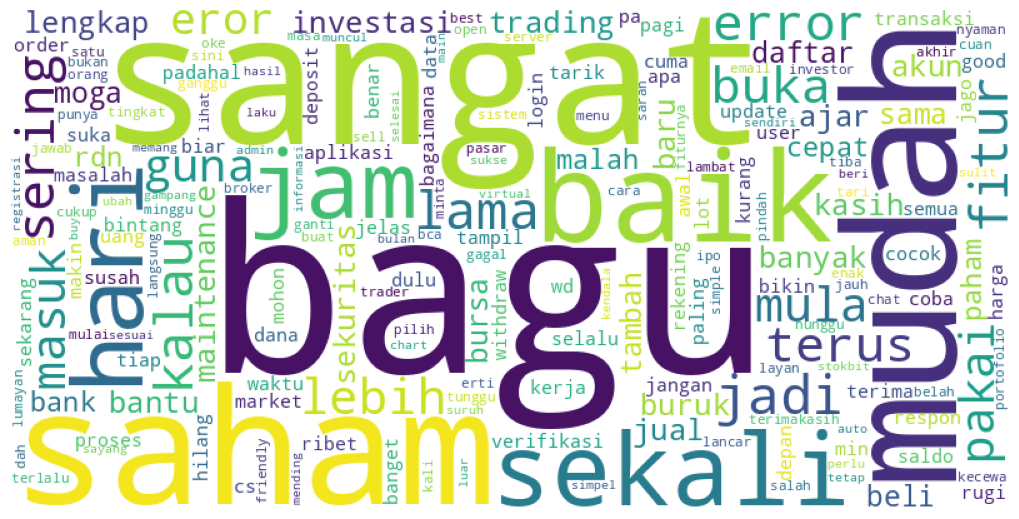

In [ ]:
all_text = ' '.join(df_stockbit_clean['final_text'].dropna().astype(str))

wordcloud = WordCloud(
    width=800, height=400,
    background_color='white',
    collocations=False
).generate(all_text)

plt.figure(figsize=(10, 5), facecolor=None)
plt.imshow(wordcloud)
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()

### Word Cloud — Positive vs Negative

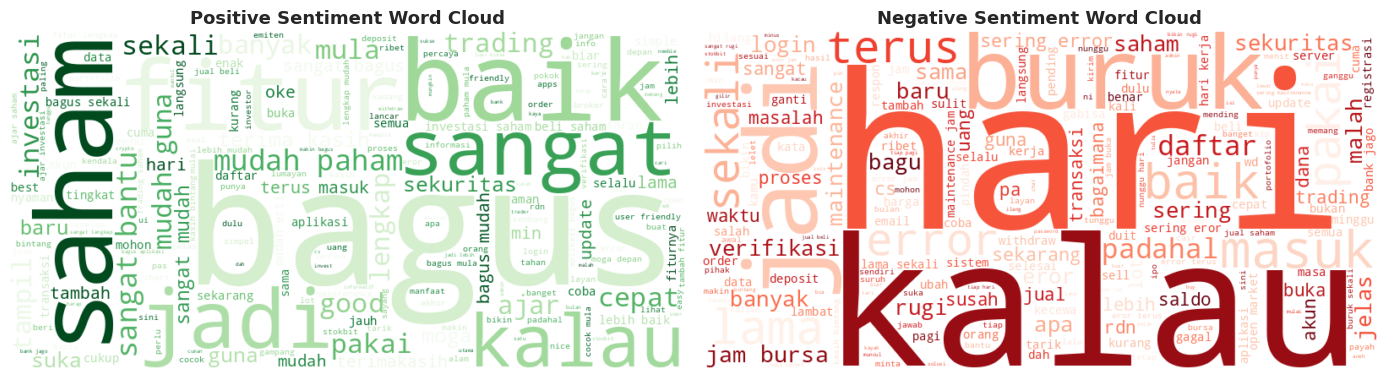

In [ ]:
if 'sentiment' in df_stockbit_clean.columns:
    positive_reviews = df_stockbit_clean[df_stockbit_clean['sentiment'] == 'positive']['final_text'].astype(str)
    negative_reviews = df_stockbit_clean[df_stockbit_clean['sentiment'] == 'negative']['final_text'].astype(str)

    positive_wc = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(' '.join(positive_reviews))
    negative_wc = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(' '.join(negative_reviews))

    plt.figure(figsize=(14, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(positive_wc, interpolation='bilinear')
    plt.title('Positive Sentiment Word Cloud', fontsize=13, fontweight='bold')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(negative_wc, interpolation='bilinear')
    plt.title('Negative Sentiment Word Cloud', fontsize=13, fontweight='bold')
    plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print('Kolom sentiment tidak ada; wordcloud per label dilewati.')

### Review Count by Year

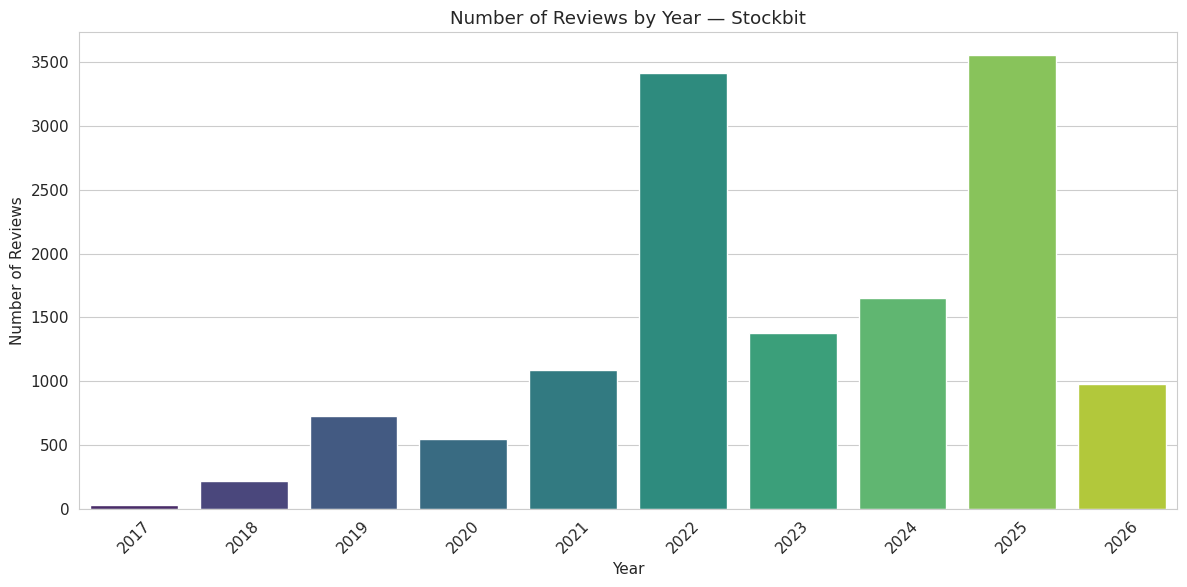

In [ ]:
if 'at' in df_stockbit_clean.columns:
    df_stockbit_clean['at'] = pd.to_datetime(df_stockbit_clean['at'], errors='coerce')
    df_stockbit_clean['year'] = df_stockbit_clean['at'].dt.year
    reviews_by_year = df_stockbit_clean.groupby('year')['content'].count() if 'content' in df_stockbit_clean.columns else df_stockbit_clean.groupby('year').size()

    plt.figure(figsize=(12, 6))
    ax = sns.barplot(x=reviews_by_year.index.astype(str), y=reviews_by_year.values, palette='viridis')
    plt.xlabel('Year')
    plt.ylabel('Number of Reviews')
    plt.title('Number of Reviews by Year — Stockbit')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print('Kolom at tidak ada; plot per tahun dilewati.')

### Distribution of Ratings

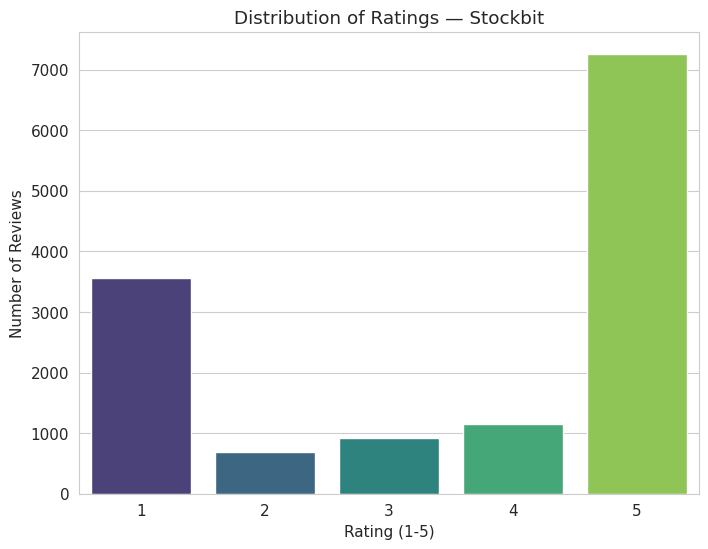

In [ ]:
if 'score' in df_stockbit_clean.columns:
    plt.figure(figsize=(8, 6))
    sns.countplot(x='score', data=df_stockbit_clean, palette='viridis')
    plt.title('Distribution of Ratings — Stockbit')
    plt.xlabel('Rating (1-5)')
    plt.ylabel('Number of Reviews')
    plt.show()
else:
    print('Kolom score tidak ada; distribusi rating dilewati.')

### Sentiment Trend Over Time (by Year)

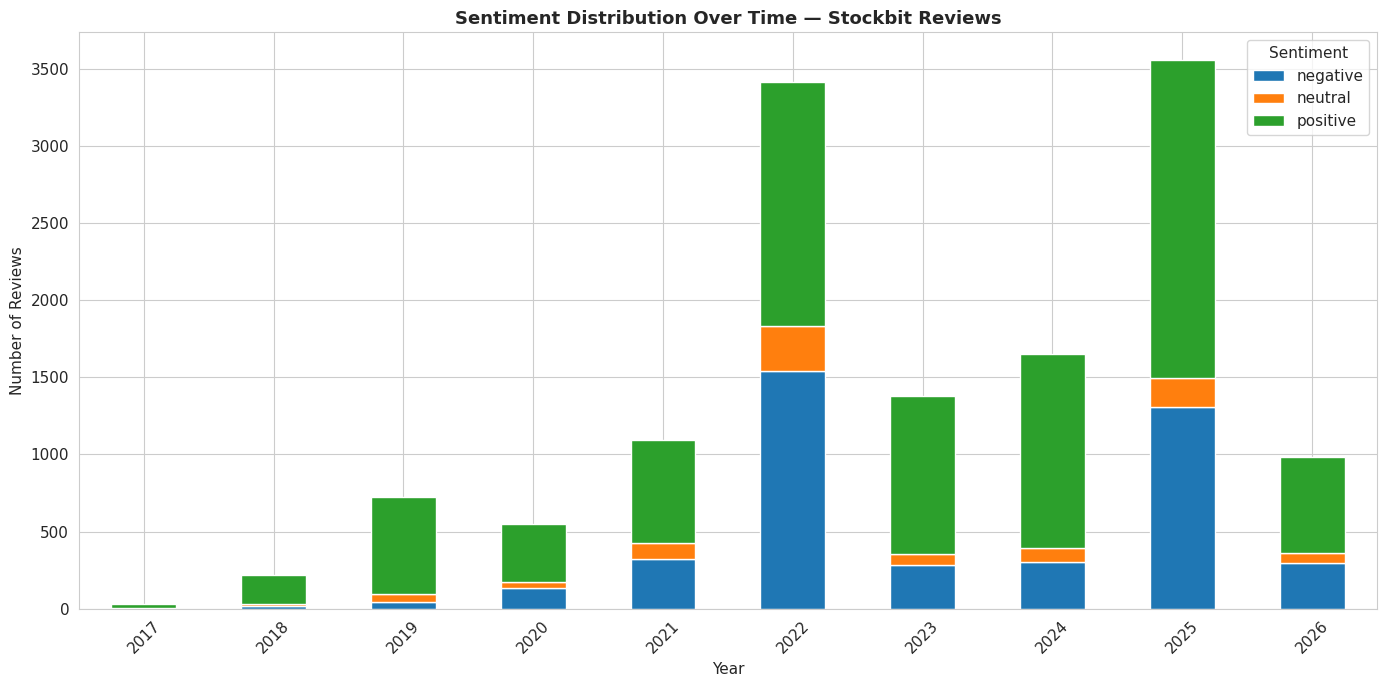

In [ ]:
if 'year' in df_stockbit_clean.columns and 'sentiment' in df_stockbit_clean.columns:
    sentiment_over_time = df_stockbit_clean.groupby(['year', 'sentiment']).size().unstack(fill_value=0)

    desired = ['negative', 'neutral', 'positive']
    for col in desired:
        if col not in sentiment_over_time.columns:
            sentiment_over_time[col] = 0
    sentiment_over_time = sentiment_over_time[desired]

    fig, ax = plt.subplots(figsize=(14, 7))
    sentiment_over_time.plot(kind='bar', stacked=True, ax=ax, edgecolor='white')
    ax.set_xlabel('Year')
    ax.set_ylabel('Number of Reviews')
    ax.set_title('Sentiment Distribution Over Time — Stockbit Reviews', fontsize=13, fontweight='bold')
    ax.legend(title='Sentiment')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print('Butuh kolom year & sentiment; trend over time dilewati.')

## 5) Save dataset with sentiment scores

In [ ]:
out_path = Path('/content/stockbit_reviews_sentiment.csv')
out_path.parent.mkdir(exist_ok=True)
df_stockbit_clean.to_csv(out_path, index=False)

print(f'Dataset saved: {out_path}')
print(f'Shape: {df_stockbit_clean.shape}')
df_stockbit_clean.head()

Dataset saved: /content/stockbit_reviews_sentiment.csv
Shape: (13592, 11)


,content,score,at,thumbsUpCount,replyContent,sentiment,final_text,tokens_stemmed,sentiment_polarity,sentiment_subjectivity,year
0,mantap,5,2026-03-28 10:49:16,0,NaN,positive,bagus,['bagus'],0.0,0.000000,2026
1,Keren. Sangat membantu. Tapi sayangnya belum a...,5,2026-03-28 10:04:59,11,"Halo kak bujanggila,\n\nTerima kasih atas upda...",positive,bagus sangat bantu sayang trailing stop ayo ja...,"['bagus', 'sangat', 'bantu', 'sayang', 'traili...",0.0,0.357143,2026
2,udh nunggu lama bgt lebih dari waktu yg di bil...,1,2026-03-28 09:19:54,0,"Halo kak Giffa,\n\nUntuk verifikasi data membu...",negative,nunggu lama banget lebih waktu bilanghari muda...,"['nunggu', 'lama', 'banget', 'lebih', 'waktu',...",0.0,0.000000,2026
3,penipuan,1,2026-03-28 08:59:03,0,NaN,negative,tipu,['tipu'],0.0,0.000000,2026
4,aplikasi investasi yang sngat dipercaya,5,2026-03-28 04:08:53,0,NaN,positive,investasi sngat percaya,"['investasi', 'sngat', 'percaya']",0.0,0.000000,2026
